<a href="https://colab.research.google.com/github/M-AKSHAYAA1410/logistics-data-analysis/blob/main/Week1_Logistics_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
df = pd.read_csv("Daily_Demand_Forecasting_Orders.csv",
                 sep=";"
                 )
print(df.shape)
print(df.head())
df.info()

(60, 13)
   Week of the month (first week, second, third, fourth or fifth week  \
0                                                  1                    
1                                                  1                    
2                                                  1                    
3                                                  2                    
4                                                  2                    

   Day of the week (Monday to Friday)  Non-urgent order  Urgent order  \
0                                   4           316.307       223.270   
1                                   5           128.633        96.042   
2                                   6            43.651        84.375   
3                                   2           171.297       127.667   
4                                   3            90.532       113.526   

   Order type A  Order type B  Order type C  Fiscal sector orders  \
0        61.543       175.586       302.448 

In [5]:
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.dtypes)

Week of the month (first week, second, third, fourth or fifth week    0
Day of the week (Monday to Friday)                                    0
Non-urgent order                                                      0
Urgent order                                                          0
Order type A                                                          0
Order type B                                                          0
Order type C                                                          0
Fiscal sector orders                                                  0
Orders from the traffic controller sector                             0
Banking orders (1)                                                    0
Banking orders (2)                                                    0
Banking orders (3)                                                    0
Target (Total orders)                                                 0
dtype: int64
0
Week of the month (first week, second, third, fou

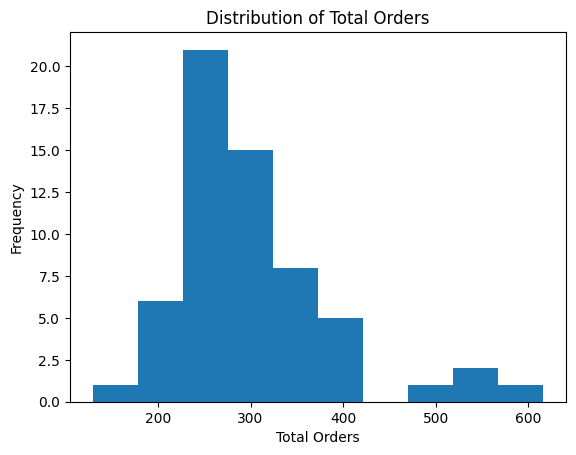

In [9]:
import matplotlib.pyplot as plt

df["Target (Total orders)"].plot(
    kind="hist",
    bins=10
)

plt.title("Distribution of Total Orders")
plt.xlabel("Total Orders")
plt.ylabel("Frequency")
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df.drop("Target (Total orders)", axis=1)
y = df["Target (Total orders)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [12]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1.9374131928392066e-12
R² Score: 1.0


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = [
    "Non-urgent order",
    "Urgent order",
    "Order type A",
    "Order type B",
    "Order type C"
]

X_cluster = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)
print(df["Cluster"].value_counts())

Cluster
0    31
2    25
1     4
Name: count, dtype: int64


In [15]:
cluster_summary = df.groupby("Cluster")[[
    "Non-urgent order",
    "Urgent order",
    "Order type A",
    "Order type B",
    "Order type C"
]].mean()

print(cluster_summary)

         Non-urgent order  Urgent order  Order type A  Order type B  \
Cluster                                                               
0              131.358355    101.669613     42.830903      78.67771   
1              358.287250    169.458750     76.353750     234.95200   
2              193.921520    132.226320     59.742400     126.99896   

         Order type C  
Cluster                
0          117.159581  
1          233.135250  
2          152.295480  
